# Clustering Inference Pipeline

Loads a trained KMeans model and cluster→resolution mapping, assigns clusters to new questions, and evaluates the accuracy vs. cost trade-off.

**Inputs**: trained model (`.pkl`), resolution mapping (`.csv`), test dataset (`.jsonl`), ground-truth scores (`.xlsx`)  
**Outputs**: per-question predictions (`question_id, cluster, resolution`), accuracy vs. cost analysis

In [13]:
# Setup: Determine project root
from pathlib import Path
import sys

# Find project root (contains pyproject.toml)
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not find project root (pyproject.toml)")
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root: {PROJECT_ROOT}")
sys.path.insert(0, str(PROJECT_ROOT))

Project root: /mnt/c/All/GitHub/scale-wise-optimizer


---
## 0 · Configuration

In [14]:
# ── Paths ────────────────────────────────────────────────────────────────────
MODEL_PATH           = str(PROJECT_ROOT / 'clustering/training/artifacts/clustering_model.pkl')                   # trained KMeans model
MAPPING_PATH         = str(PROJECT_ROOT / 'clustering/training/results/cluster_resolution_mapping.csv')         # cluster → resolution lookup
TEST_DATASET         = str(PROJECT_ROOT / 'benchmarks/seedbench/test.jsonl')                   # test questions (one JSON per line, must have 'input' and 'doc_id')

# ── Resolution tokens (must match training) ──────────────────────────────────
RESOLUTIONS = ['25000', '50000', '100000',
               '150000', '250000', '400000', '600000', '800000']

# ── Strategy column from the mapping to use as the default recommendation ────
#    Options: 'best_resolution', 'efficient_res_95pct', 'efficient_res_99pct'
STRATEGY = 'efficient_res_95pct'

# ── Output ───────────────────────────────────────────────────────────────────
PREDICTIONS_OUTPUT = str(PROJECT_ROOT / 'clustering/inference/results/test_predictions.csv')

---
## 1 · Load artifacts

In [15]:
import json, re, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer

sns.set_style('whitegrid')
%matplotlib inline

# ── Load trained model ────────────────────────────────────────────────────────
with open(MODEL_PATH, 'rb') as f:
    artefacts = pickle.load(f)

kmeans          = artefacts['kmeans']
embedding_model = artefacts['embedding_model']
optimal_k       = artefacts['optimal_k']

print(f'KMeans loaded  ·  K = {optimal_k}  ·  embedding model = {embedding_model}')

# ── Load cluster → resolution mapping ─────────────────────────────────────────
df_mapping = pd.read_csv(MAPPING_PATH)
print(f'Mapping loaded ·  {len(df_mapping)} clusters')

df_mapping.head()


KMeans loaded  ·  K = 29  ·  embedding model = all-MiniLM-L6-v2
Mapping loaded ·  29 clusters


,cluster,n_questions,best_resolution,best_accuracy,efficient_res_95pct,acc_at_95pct,efficient_res_99pct,acc_at_99pct
0,0,223,600000,0.717489,150000,0.708520,600000,0.717489
1,1,546,800000,0.789377,150000,0.758242,800000,0.789377
2,2,256,800000,0.773438,250000,0.753906,800000,0.773438
3,3,642,800000,0.802181,250000,0.767913,800000,0.802181
4,4,680,800000,0.720588,400000,0.704412,800000,0.720588


---
## 2 · Load artifacts

In [16]:
# ── Read test questions + scores direto do JSONL ──────────────────────────────
records = []

with open(TEST_DATASET, 'r', encoding='utf-8') as f:
    for line in f:
        obj = json.loads(line)

        row = {
            'doc_id': obj.get('doc_id'),
            'input':  obj.get('input', ''),
        }

        for res in RESOLUTIONS:
            row[res] = obj.get('scores', {}).get(res, np.nan)

        records.append(row)

df_test = pd.DataFrame(records)


# ── Clean question text (same transform as training) ──────────────────────────
def clean_input(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.replace(
        "Answer with the option's letter from the given choices directly.", ''
    ).strip()

    match = re.search(r'\n[A-D]\.\s', text)
    return text[:match.start()].strip() if match else text


df_test['question_stem'] = df_test['input'].apply(clean_input)

print(f'Test set: {len(df_test)} questions')


Test set: 2847 questions


---
## 3 · Predict clusters & assign resolutions

In [17]:
# ── Embed ─────────────────────────────────────────────────────────────────────
encoder = SentenceTransformer(embedding_model)
embeddings = encoder.encode(df_test['question_stem'].tolist(), show_progress_bar=True)
print(f'Embeddings: {embeddings.shape}')

# ── Predict (uses the trained centroids, no re-fitting) ───────────────────────
df_test['cluster'] = kmeans.predict(embeddings)

# ── Lookup resolution from mapping ────────────────────────────────────────────
resolution_lookup = df_mapping.set_index('cluster')[STRATEGY].to_dict()
df_test['resolution'] = df_test['cluster'].map(resolution_lookup)

print(f'Assigned clusters: {df_test["cluster"].nunique()} unique')
print(f'Strategy: {STRATEGY}')

Batches: 100%|██████████| 89/89 [00:06<00:00, 13.35it/s]


Embeddings: (2847, 384)
Assigned clusters: 29 unique
Strategy: efficient_res_95pct


---
## 4 · Save predictions

In [18]:
# ── Final output: question_id → cluster → resolution ──────────────────────────
os.makedirs(os.path.dirname(PREDICTIONS_OUTPUT), exist_ok=True)

id_col = 'question_id' if 'question_id' in df_test.columns else 'doc_id'
df_predictions = df_test[[id_col, 'cluster', 'resolution']].copy()
df_predictions.to_csv(PREDICTIONS_OUTPUT, index=False)

print(f'Saved {len(df_predictions)} predictions → {PREDICTIONS_OUTPUT}')
df_predictions.head(10)

Saved 2847 predictions → /mnt/c/All/GitHub/scale-wise-optimizer/clustering/inference/results/test_predictions.csv


,doc_id,cluster,resolution
0,8,18,250000
1,14,24,400000
2,15,15,100000
3,19,5,250000
4,27,27,100000
5,31,24,400000
6,33,3,250000
7,35,25,50000
8,36,13,400000
9,39,3,250000


---
## 5 · Evaluation — Cluster distribution

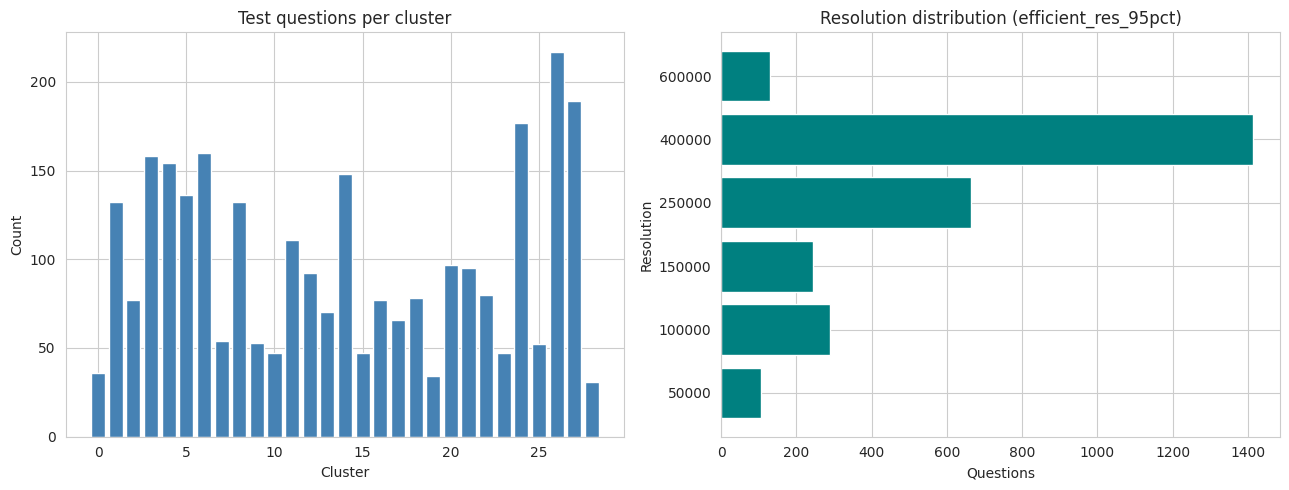

In [19]:
cluster_counts = df_test['cluster'].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
ax1.bar(cluster_counts.index, cluster_counts.values, color='steelblue', edgecolor='white')
ax1.set_xlabel('Cluster'); ax1.set_ylabel('Count')
ax1.set_title('Test questions per cluster')

# Assigned resolution distribution
res_counts = df_test['resolution'].astype(str).value_counts().sort_index(key=lambda x: x.astype(int))
ax2.barh(res_counts.index, res_counts.values, color='teal', edgecolor='white')
ax2.set_xlabel('Questions'); ax2.set_ylabel('Resolution')
ax2.set_title(f'Resolution distribution ({STRATEGY})')

plt.tight_layout()
plt.show()

---
## 6 · Evaluation — Accuracy vs. computational cost

In [20]:
MAX_RES = max(int(r) for r in RESOLUTIONS)
n_test  = len(df_test)

def _strategy_metrics(df, res_series):
    """Weighted accuracy and relative cost for a given per-question resolution series."""
    correct = sum(
        df.iloc[i][str(int(res_series.iloc[i]))] for i in range(len(df))
    )
    cost = res_series.astype(int).sum()
    return correct / n_test, cost / (n_test * MAX_RES) * 100

# ── Fixed-resolution baselines ────────────────────────────────────────────────
rows = []
for res in RESOLUTIONS:
    acc  = df_test[res].mean()
    cost = int(res) / MAX_RES * 100
    rows.append({'strategy': f'Fixed {res}', 'accuracy': acc, 'cost_pct': cost})

df_fixed = pd.DataFrame(rows)

# ── Cluster-based strategies ──────────────────────────────────────────────────
mapping_dict = df_mapping.set_index('cluster')
cluster_strat_rows = []

for label, col in [('Best per cluster', 'best_resolution'),
                    ('Efficient (95%)',  'efficient_res_95pct'),
                    ('Efficient (99%)',  'efficient_res_99pct')]:
    res_per_q = df_test['cluster'].map(mapping_dict[col].to_dict()).astype(str)
    acc, cost = _strategy_metrics(df_test, res_per_q)
    cluster_strat_rows.append({'strategy': label, 'accuracy': acc, 'cost_pct': cost})

df_cluster_strat = pd.DataFrame(cluster_strat_rows)
df_all = pd.concat([df_fixed, df_cluster_strat], ignore_index=True)

print('Strategy comparison on test set:')
df_all.round(4)

Strategy comparison on test set:


,strategy,accuracy,cost_pct
0,Fixed 25000,0.5996,3.1250
1,Fixed 50000,0.6421,6.2500
2,Fixed 100000,0.6684,12.5000
3,Fixed 150000,0.6913,18.7500
4,Fixed 250000,0.6990,31.2500
5,Fixed 400000,0.7183,50.0000
6,Fixed 600000,0.7278,75.0000
7,Fixed 800000,0.7383,100.0000
8,Best per cluster,0.7299,91.8247
9,Efficient (95%),0.7106,38.6416


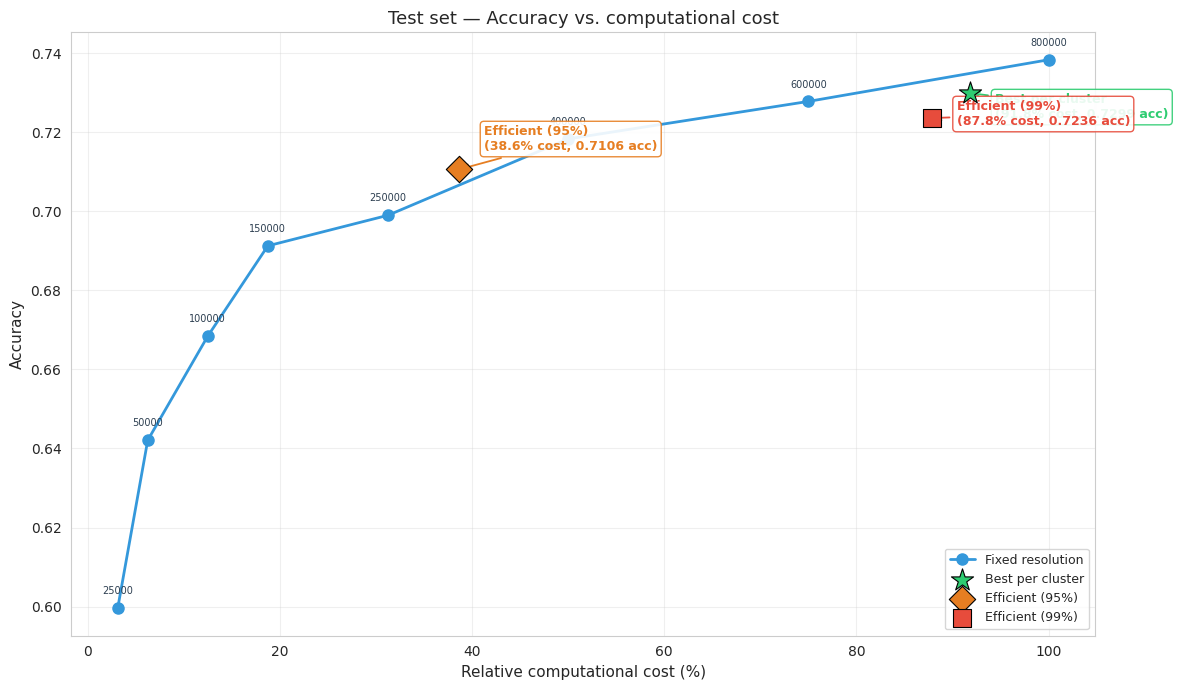

In [21]:
fig, ax = plt.subplots(figsize=(12, 7))

# ── Fixed-resolution curve ────────────────────────────────────────────────────
ax.plot(df_fixed['cost_pct'], df_fixed['accuracy'],
        'o-', color='#3498db', lw=2, ms=8, label='Fixed resolution', zorder=3)

for _, r in df_fixed.iterrows():
    ax.annotate(r['strategy'].replace('Fixed ', ''),
                (r['cost_pct'], r['accuracy']),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=7, color='#2c3e50')

# ── Cluster strategies ────────────────────────────────────────────────────────
style = {
    'Best per cluster': ('*',  '#2ecc71', 280),
    'Efficient (95%)':  ('D',  '#e67e22', 180),
    'Efficient (99%)':  ('s',  '#e74c3c', 180),
}

for _, r in df_cluster_strat.iterrows():
    mk, co, sz = style[r['strategy']]
    ax.scatter(r['cost_pct'], r['accuracy'],
               marker=mk, c=co, s=sz, zorder=5,
               edgecolors='black', linewidth=0.8, label=r['strategy'])
    ax.annotate(
        f"{r['strategy']}\n({r['cost_pct']:.1f}% cost, {r['accuracy']:.4f} acc)",
        (r['cost_pct'], r['accuracy']),
        textcoords='offset points',
        xytext=(18, -18) if 'Best' in r['strategy'] else (18, 14) if '95' in r['strategy'] else (18, -5),
        fontsize=9, fontweight='bold', color=co,
        arrowprops=dict(arrowstyle='->', color=co, lw=1.3),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=co, alpha=0.9))

ax.set_xlabel('Relative computational cost (%)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Test set — Accuracy vs. computational cost', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7 · Evaluation — Per-cluster accuracy on test set

In [22]:
# Accuracy per cluster at the assigned resolution vs. at max resolution
rows = []
for cid, grp in df_test.groupby('cluster'):
    assigned_res = str(int(grp['resolution'].iloc[0]))
    rows.append({
        'cluster': cid,
        'n_test': len(grp),
        'assigned_resolution': assigned_res,
        'acc_at_assigned': grp[assigned_res].mean(),
        'acc_at_max': grp[RESOLUTIONS[-1]].mean(),
    })

df_eval = pd.DataFrame(rows).sort_values('cluster')
df_eval['acc_gap'] = df_eval['acc_at_max'] - df_eval['acc_at_assigned']

print(f'Mean accuracy gap (max − assigned): {df_eval["acc_gap"].mean():.4f}')
df_eval.round(4)

Mean accuracy gap (max − assigned): 0.0342


,cluster,n_test,assigned_resolution,acc_at_assigned,acc_at_max,acc_gap
0,0,36,150000,0.6944,0.7500,0.0556
1,1,132,150000,0.8030,0.7727,-0.0303
2,2,77,250000,0.7662,0.7532,-0.0130
3,3,158,250000,0.7468,0.7532,0.0063
4,4,154,400000,0.6364,0.6883,0.0519
5,5,136,250000,0.6324,0.6471,0.0147
6,6,160,400000,0.6688,0.6750,0.0063
7,7,54,50000,0.8889,0.8704,-0.0185
8,8,132,400000,0.7652,0.8182,0.0530
9,9,53,100000,0.6415,0.7170,0.0755


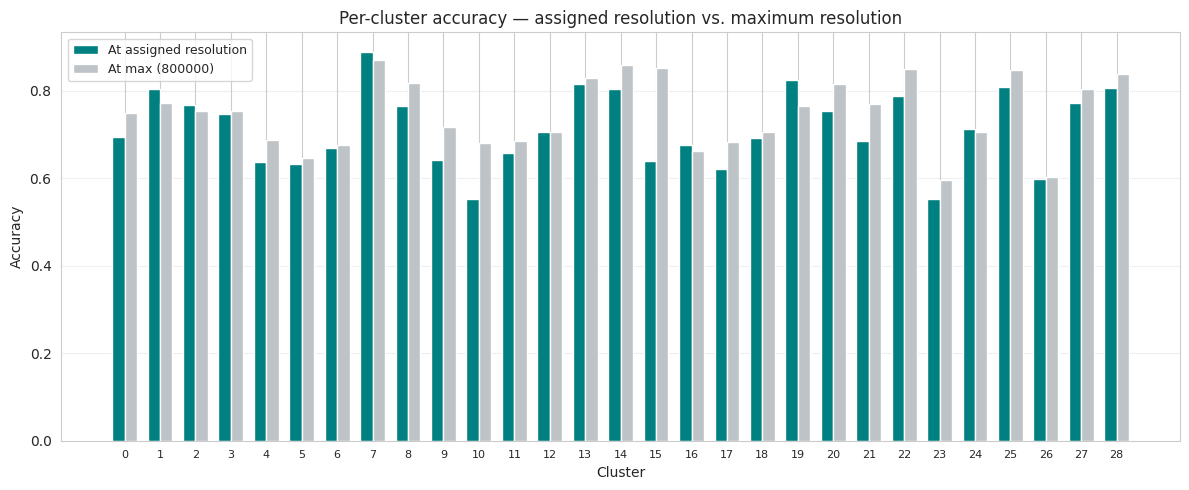

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(df_eval))
w = 0.35

ax.bar(x - w/2, df_eval['acc_at_assigned'], w, label='At assigned resolution', color='teal',   edgecolor='white')
ax.bar(x + w/2, df_eval['acc_at_max'],      w, label=f'At max ({RESOLUTIONS[-1]})', color='#bdc3c7', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(df_eval['cluster'], fontsize=8)
ax.set_xlabel('Cluster'); ax.set_ylabel('Accuracy')
ax.set_title('Per-cluster accuracy — assigned resolution vs. maximum resolution')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()